<a href="https://colab.research.google.com/github/Moharram-Khaled/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Moharram-Khaled/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Ranking Signal Analysis for Content Action Prioritization

A decision-support analysis for identifying content pages that may warrant ranking and optimization review.

## Abstract

This study asks whether observable search and traffic signals can help prioritize content pages for ranking-opportunity review. Using the FlyRank ML Internship dataset, I built a page-level decision-support workflow using search visibility, average search position, and click signals. A baseline ranking score was compared with a Logistic Regression model using both a random split and a client-grouped validation split. The Logistic Regression model achieved an F1 score of 0.387 on the random split and 0.319 on the grouped-by-client split, showing that validation design materially affects the measured result. The resulting signals are therefore best used for directional prioritization and human review rather than automatic content decisions.

## 1. Introduction / Problem Statement

Content teams often have more pages to review than they can manually investigate. The practical problem is deciding which pages should receive attention first.

This study explores whether observable search-performance signals can provide useful decision-support for prioritizing content pages for ranking review.

The goal is not to prove that a particular optimization will improve rankings. Instead, the goal is to build and validate a transparent workflow that ranks pages for human investigation while making its limitations explicit.

## 2. Data

The analysis uses the FlyRank ML Internship dataset and focuses on the `fact_content_daily_performance` table.

The daily performance table contains page-client-date observations with Google Search Console and GA4-derived signals.

For the main modeling workflow, March 2026 was used as the feature window and April 2026 as the future outcome window. The analysis used hashed client and content identifiers and did not expose client names, URLs, or private search queries.

The working features included:

- `gsc_impressions`
- `gsc_avg_position`
- `gsc_clicks`

The analysis excluded future-derived outcome information from the feature set to avoid target leakage.

The dataset contains varying GSC and GA4 availability, so incomplete source coverage is an important consideration when interpreting the results.

## 3. Methodology

### Unit of analysis

The unit of analysis is one content page for one client, represented by a daily observation in the performance table. For modeling, observations were aggregated into a page-client feature representation for the decision window.

### Target

The target is a binary future movement proxy:

- `1` = future average position improved
- `0` = future average position did not improve

The target is used as a directional proxy rather than a causal measure of optimization success.

### Features

The model uses observable signals from the decision window:

- GSC impressions
- GSC average position
- GSC clicks

No future outcome fields are used as model features.

### Baseline

The Week-4 baseline ranks pages using a simple action score combining percentile-ranked impressions and average position.

The baseline is intentionally transparent and serves as the benchmark for the modeling work.

### Model

A Logistic Regression model was selected because the target is binary and the model provides a simple, interpretable benchmark without unnecessary complexity.

### Validation

Two validation designs were compared:

1. Random train/test split.
2. Client-grouped split, where no client appears in both training and test sets.

The grouped split provides a stricter test of generalization to unseen clients.

### Leakage checks

Feature columns were compared against target-derived fields, and client overlap between the grouped training and test sets was checked. The grouped split had zero client overlap.

## 4. Results (vs baseline)

The model was evaluated against a simple baseline using the same evaluation framework.

| Method | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Majority baseline | 0.578 | 0.000 | 0.000 | 0.000 |
| Logistic Regression | 0.637 | 0.650 | 0.302 | 0.413 |

The Week-6 validation audit then compared a random split with a client-grouped split:

| Validation design | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Random split | 0.689 | 0.630 | 0.279 | 0.387 |
| Grouped by client | 0.768 | 0.443 | 0.249 | 0.319 |

The grouped split contained 34 training clients and 12 test clients, with zero client overlap.

The decrease in F1 from 0.387 to 0.319 indicates that performance is more difficult to maintain when evaluating on unseen clients. Therefore, the grouped result is the more conservative estimate for generalization across clients.

### Error analysis

The validation analysis produced 1,592 false positives and 3,810 false negatives.

False positives represent pages predicted to improve that did not improve in the future window. False negatives represent pages that improved but were not identified by the model.

The examples show that search visibility and average position do not capture every factor associated with future ranking movement. Some pages with substantial impressions still moved in the wrong direction, while some pages with relatively weak signals improved.

These errors support treating the model as directional decision-support rather than as an automatic ranking predictor.

## 5. Limitations

This analysis has several limitations.

First, the target is a future position-movement proxy rather than a direct measure of the success of a content optimization intervention.

Second, performance varies depending on validation design. The grouped client split produced a lower F1 score than the random split.

Third, GSC and GA4 availability is not uniform across all observations, which can create incomplete feature coverage.

Fourth, the available signals do not capture every factor that may influence search performance, including query-level intent and other contextual information.

Finally, the analysis is observational. It does not establish that changing or refreshing content causes ranking improvement.

The results should therefore be described as observed, measured, directional, and useful for decision-support rather than as causal or production-grade predictions.

## 6. Ranked recommendations

## 6. Ranked Recommendations

The action playbook converts the observed signals into a ranked review queue.

### 1. Review high-visibility pages with weaker positions

Reason code: `high_visibility_low_position`

Action: `review_ranking_opportunity`

These pages should receive human review because they have meaningful search exposure but may have room for ranking improvement.

### 2. Check search intent before changing content

A high action score does not prove that content should be rewritten. Reviewers should confirm that the queries generating visibility are relevant to the page.

### 3. Consider freshness as context

Older content may warrant review for potential decay or staleness, but freshness should not automatically trigger a content refresh.

### 4. Prioritize evidence quality

Pages with incomplete data should receive additional investigation before expensive content work.

### 5. Keep humans in the loop

The score should prioritize review rather than automatically publish, rewrite, redirect, or remove content.

## 7. Artifacts the paper embeds

### No-go cases

The following actions should not be automated based only on the model or baseline score:

- Publishing rewritten content.
- Changing search intent.
- Removing or redirecting pages.
- Automatically changing titles or headings.
- Automatically applying internal-link changes.
- Treating a prediction as proof of ranking improvement.
- Making decisions from incomplete data without human review.



## Reproducibility

The analysis was developed as a sequence of notebooks covering:

- ML task framing
- Data contract
- Baseline action scoring
- Capstone modeling
- Validation and research-claim audit
- Content action playbook

The complete work is available in the project repository, including the executed notebooks and generated analysis artifacts.

The paper is intended to remain reproducible from the public repository without exposing private client information.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: [FlyRank](https://flyrank.ai)

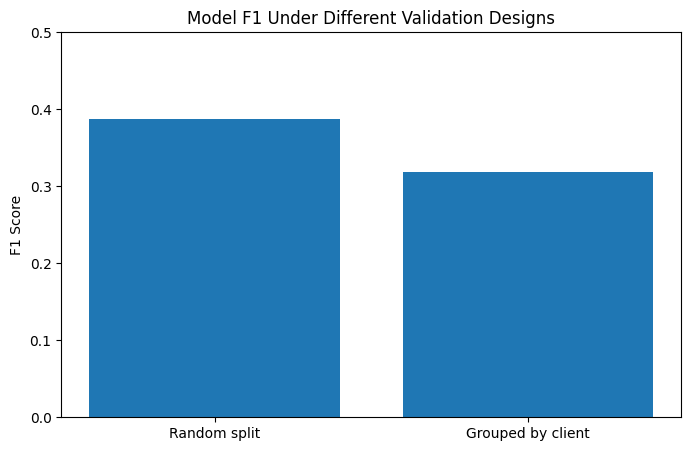

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Validation": [
        "Random split",
        "Grouped by client"
    ],
    "F1": [
        0.387023,
        0.319133
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(results["Validation"], results["F1"])
plt.ylabel("F1 Score")
plt.title("Model F1 Under Different Validation Designs")
plt.ylim(0, 0.5)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
